<a href="https://colab.research.google.com/github/GyeongHub/ESAA-OB/blob/main/week5_0331_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*0331(월) 5주차 과제*\
*파이썬 머신러닝 완벽 가이드 8장 텍스트 분석 - 06, 08, 09 p.534-538, p.550-565*

# 06. 토픽 모델링(Topic Modeling) — 20 뉴스그룹

**토픽 모델링(Topic Modeling)**
- 문서 집합에 숨어 있는 주제를 찾아내는 것

**머신러닝 기반 토픽 모델링에 자주 사용되는 기법**
- LSA(Latent Semantic Analysis)
- LDA(Latent Dirichlet Analysis): 이 절에서 살펴봄
    - 차원 축소의 LDA(Linear Discriminant Analysis)와는 다른 알고리즘임.

**20 뉴스그룹 데이터의 주제들**

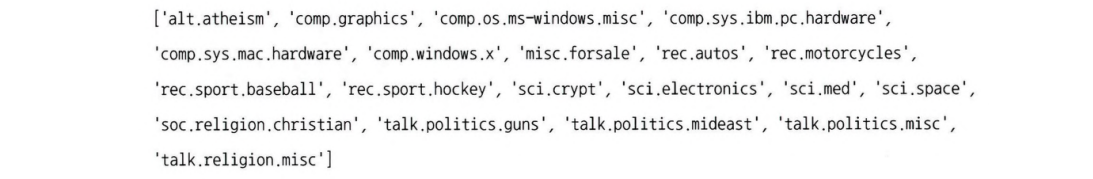

- 사이킷런은 LDA(Latent Dirichlet Allocation) 기반의 토픽 모델링을 LatentDirichletAllocation 클래스로 제공

In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 모터사이클, 야구, 그래픽스, 윈도우즈, 중동, 기독교, 전자공학, 의학 8개 주제를 추출
cats = ['rec.motorcycles', 'rec.sport.baseball', 'comp.graphics', 'comp.windows.x', 'talk.politics.mideast', 'soc.religion.christian', 'sci.electronics', 'sci.med']

# 위에서 cats 변수로 기재된 카테고리만 추출.
# featch_20newsgroups( )의 categories 파라미터에 cats 입력
news_df = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'),
                             categories=cats, random_state=0)

# LDA는 Count 기반의 벡터화만 적용함.
count_vect = CountVectorizer(max_df=0.95, max_features=1000, min_df=2, stop_words='english', ngram_range=(1,2))
feat_vect = count_vect.fit_transform(news_df.data)
print('CountVectorizer Shape:', feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


- feat_vect: 7862개의 문서가 1000개의 피처로 구성된 행렬 데이터.

In [2]:
# 피처 벡터화된 데이터 세트를 기반으로 LDA 토픽 모델링을 수행
# LatentDirichletAllocation 클래스의 n_components 파라미터를 이용해 이 토픽 개수를 8개로 조정

lda = LatentDirichletAllocation(n_components=8, random_state=0)
lda.fit(feat_vect)

LatentDirichletAllocation(n_components=8, random_state=0)

- LatentDirichletAllocation.fit(데이터 세트) 수행
    - LatentDirichletAllocation 객체는 components_ 속성값을 가지게 됨
    - components_: 개별 토픽별로 각 word 피처가 얼마나 많이 그 토픽에 할당됐는지에 대한 수치

In [3]:
# components_의 형태와 속성값 확인
print(lda.components_.shape)

(8, 1000)


In [4]:
lda.components_

array([[2.69030238e+02, 1.87798026e+02, 7.09003824e+01, ...,
        1.22710343e+01, 1.06329639e+02, 7.25995512e+01],
       [1.25091799e-01, 2.46049106e+00, 1.25051902e-01, ...,
        2.80071176e+02, 1.25089783e-01, 5.05669662e+01],
       [1.33978420e+02, 1.25042012e-01, 9.98277256e+01, ...,
        1.25092219e-01, 3.31078261e+01, 1.25028398e-01],
       ...,
       [2.98813886e+01, 1.88071366e+01, 1.14748730e+01, ...,
        1.93022584e+01, 5.29368271e+00, 1.44478198e+01],
       [1.25074899e-01, 1.25105300e-01, 1.25004235e-01, ...,
        1.03576436e+02, 1.25100535e-01, 7.22276359e+01],
       [1.25172284e-01, 1.03967760e+00, 1.25221075e-01, ...,
        5.31740996e+01, 1.25025929e-01, 1.25062991e-01]])

- components_는 array[8, 1000]으로 구성.
- 8개의 토픽별로 1000개의 word 피처가 해당 토픽 별로 연관도 값을 가짐.

In [5]:
# lda_model.components_ 값만으로는 각 토픽별 word 연관도를 보기가 어려움
# display_topics( ) 함수 -> 각 토픽별로 연관도가 높은 순으로 Word 나열

def display_topics(model, feature_names, no_top_words):
    for topic_index, topic in enumerate(model.components_):
        print('Topic #', topic_index)

        # components_array에서 가장 값이 큰 순으로 정렬했을 때, 그 값의 array 인덱스를 반환.
        topic_word_indexes = topic.argsort()[::-1]
        top_indexes = topic_word_indexes[:no_top_words]

        # top_indexes대상인 인덱스별로 feature_names에 해당하는 word feature 추출 후 join으로 concat
        feature_concat = ' '.join([feature_names[i] for i in top_indexes])
        print(feature_concat)

# CountVectorizer 객체 내의 전체 word의 명칭을 get_features_names( )를 통해 추출
feature_names = count_vect.get_feature_names_out()

# Topic별 가장 연관도가 높은 word를 15개만 추출
display_topics(lda, feature_names, 15)

Topic # 0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic # 1
don just like know think good time ve does way really people want ll right
Topic # 2
image file jpeg output program gif images format files color entry use bit 03 02
Topic # 3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic # 4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic # 5
edu com available graphics ftp window use mail data motif software version pub information server
Topic # 6
god people jesus church believe say christ does christian think christians did know bible man
Topic # 7
thanks use using does help like display need problem know server screen windows window program


**결과**\
8개의 토픽으로 모델링이 잘 됐는지 확인
- Topic #0
    - 일부 불분명한 주제어들이 있지만 주로 의학에 관련된 주제어가 추출됨.
- Topic #1
    - 명확하지 않고 일반적인 단어가 주를 이룸.
- Topic #2
    - 컴퓨터 그래픽스 영역의 주제어가 다수 포함.
- Topic #3
    - 일반적인 단어로 주제어가 추출.
- Topic #4
    - 명확하게 중동 영역의 주제어가 추출.
- Topic #5
    - 일부 컴퓨터 그래픽스 영역의 주제어를 포함하고 있지만, 전반적인 컴퓨터 관련 용어들을 가지고 있어서 8개 토픽 중 하나로 매핑하기는 어려움.
- Topic #6
    - 명확하게 기독교 관련 주제어가 추출.
- Topic #7
    - 윈도우 운영체제와 관련된 주제어가 추출.
    
    
- Topic #1, Topic #3 Topic #5가 주로 애매한 주제어가 추출.
- 특히 모터사이클, 야구 주제의 경우 명확한 주제어가 추출되지 않음.

# 08. 문서 유사도

**문서 유사도 측정 방법 - 코사인 유사도**
- 두 벡터 사이의 사잇각을 구해서 얼마나 유사한지 수치로 적용한 것
- 벡터와 벡터 간의 유사도를 비교할 때 벡터의 크기보다는 벡터의 상호 방향성이 얼마나 유사한지에 기반함.

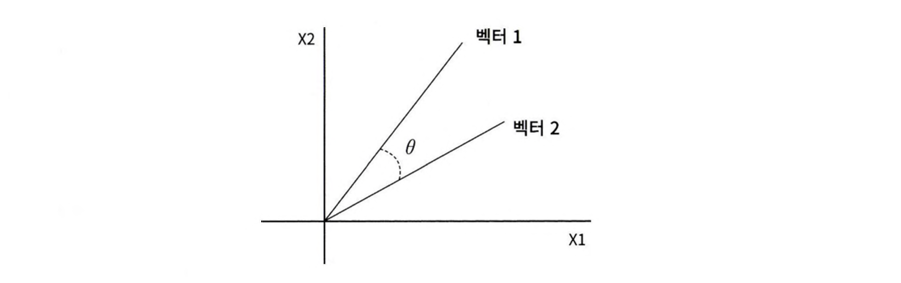

**두 벡터 사잇각**

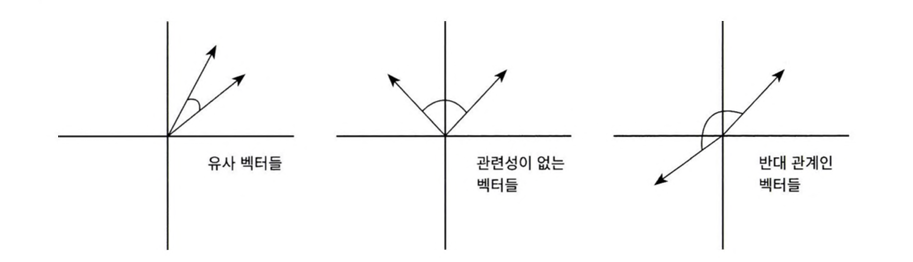

**두 벡터 A와 B의 코사인 값 구하는 식**

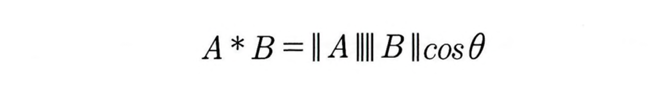

**유사도 cos$\theta$**
- 두 벡터의 내적을 총 벡터 크기의 합으로 나눈 것
- 내적 결과를 총 벡터 크기로 정규화(L2 Norm)한 것

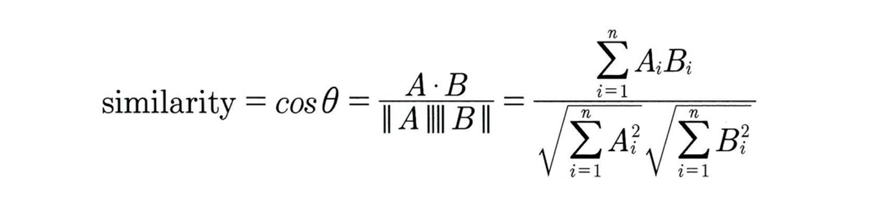

**코사인 유사도가 문서의 유사도 비교에 가장 많이 사용되는 이유**
- 문서를 피처 벡터화 변환하면 차원이 매우 많은 희소 행렬이 됨
- 희소 행렬에서 문서와 문서 벡터 간의 크기에 기반한 유사도 지표(ex. 유클리드 거리)는 정확도가 떨어짐.

In [6]:
# 문서 유사도를 코사인 유사도 기반으로 구해 보기
# 코사인 유사도를 구하는 cos_similarity() 함수 작성

import numpy as np

def cos_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    l2_norm = (np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2))))
    similarity = dot_product / l2_norm

    return similarity

In [7]:
# TF-IDF로 벡터화된 행렬로 변환

from sklearn.feature_extraction.text import TfidfVectorizer

doc_list = ['if you take the blue pill, the story ends',
            'if you take the red pill, you stay in wonderland',
            'if you take the red pill, I show you how deep the rabbit hole goes']

tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)

(3, 18)


In [8]:
# TFidfVectorizer로 transform()한 결과는 희소 행렬이므로 밀집 행렬로 변환.
feature_vect_dense = feature_vect_simple.todense()

# 첫 번째 문장과 두 번째 문장의 피처 벡터 추출
vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect2 = np.array(feature_vect_dense[1]).reshape(-1, )

# 첫 번째 문장과 두 번째 문장의 피처 벡터로 두 개 문장의 코사인 유사도 추출
similarity_simple = cos_similarity(vect1, vect2)
print('문장 1, 문장 2 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 2 Cosine 유사도: 0.402


- 첫 번째 문장과 두 번째 문장의 코사인 유사도는 0.402

In [9]:
# 첫번째와 세번째 문장의 코사인 유사도 특정

vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )

similarity_simple = cos_similarity(vect1, vect3)
print('문장 1, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 3 Cosine 유사도: 0.404


- 첫 번째 문장과 세 번째 문장의 코사인 유사도는 0.404

In [10]:
# 두번째와 세번째 문장의 코사인 유사도 측정

vect2 = np.array(feature_vect_dense[1]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )

similarity_simple = cos_similarity(vect2, vect3)
print('문장 2, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 2, 문장 3 Cosine 유사도: 0.456


- 두 번째 문장과 세 번째 문장의 코사인 유사도는 0.456

---

- 사이킷런은 코사인 유사도를 측정하기 위해 sklearn. metrics. pairwise.cosine_similarity API를 제공함.
- cosine_similarity() 함수
    - 첫 번째 파라미터: 비교 기준이 되는 문서의 피처 행렬
    - 두 번째 파라미터: 비교되는 문서의 피처 행렬
    - 희소 행렬, 밀집 행렬 모두 가능하며, 행렬 또는 배열 모두 가능
    - cos_similarity() 함수와 같이 별도의 변환 작업이 필요 없음

In [11]:
# . 첫 번째 문서와 첫 번째, 두 번째, 세 번째 문서 유사도 측정

from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple)
print(similarity_simple_pair)

[[1.         0.40207758 0.40425045]]


**결과**
- 첫 번째 유사도 값 1: 비교 기준인 첫 번째 문서 자신에 대한 유사도
- 두 번째 유사도 값 0.40207758: 첫 번째 문서와 두 번째 문서의 유사도
- 세 번째 유사도 값 0.40425045: 첫 번째 문서와 세 번째 문서의 유사도

In [12]:
# 기준 문서 제외
# 비교 대상에서 feature_vect[1: ]을 이용

similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.40425045]]


---
- cosine_similarity(): 쌍으로(pair) 코사인 유사도 값 제공 가능
    - 1번째 문서와 2, 3번째 문서의 코사인 유사도
    - 2번째 문서와 1, 3번째 문서의 코사인 유사도
    - 3번째 문서와 1, 2번째 문서의 코사인 유사도를 ndarray 형태로
제공

In [13]:
similarity_simple_pair = cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


- cosine_similarity()의 반환 값: (3,3)형태의 ndarray
    - 첫 번째 로우: 1번 문서와 2, 3번째 문서의 코사인 유사도
    - 두 번째 로우: 2번 문서와 1, 3번째 문서의 코사인 유사도
    - 세 번째 로우: 3번 문서와 1, 2번째 문서의 코사인 유사도

---

**Opinion Review 데이터 세트를 이용한 문서 유사도 측정**


In [14]:
import pandas as pd
import glob, os
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

from google.colab import drive
drive.mount('/content/drive')

# 필수 NLTK 데이터 다운로드
nltk.download('punkt')
nltk.download('wordnet')

# 데이터 불러오기
path = r'/content/drive/MyDrive/ESAA/OB/data/OpinosisDataset1.0_0/topics'
all_files = glob.glob(os.path.join(path, "*.data"))
filename_list = []
opinion_text = []

for file_ in all_files:
    df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')
    filename_ = file_.split('/')[-1]
    filename = filename_.split('.')[0]
    filename_list.append(filename)
    # Convert the DataFrame to a string before appending it to the list
    opinion_text.append(df.to_string())

document_df = pd.DataFrame({'filename': filename_list, 'opinion_text': opinion_text})


# 텍스트 정규화 및 토큰화
def LemNormalize(text):
    wordnet_lemmatizer = WordNetLemmatizer()
    words = word_tokenize(text)  # nltk 토큰화 적용
    return [wordnet_lemmatizer.lemmatize(word) for word in words]


# 빈 문서 제거
document_df = document_df.dropna(subset=['opinion_text'])

# Ensure the 'opinion_text' column contains strings
document_df['opinion_text'] = document_df['opinion_text'].astype(str)

document_df = document_df[document_df['opinion_text'].str.len() > 0]

# TF-IDF 벡터화 (stop_words 제거, min_df 완화)
tfidf_vect = TfidfVectorizer(tokenizer=None, preprocessor=None,
                             ngram_range=(1,2), min_df=0.01, max_df=0.95)
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])


# KMeans 클러스터링
km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0, n_init='auto')
km_cluster.fit(feature_vect)

# 클러스터 결과 저장
document_df['cluster_label'] = km_cluster.labels_

# 희소 행렬 변환 후 cluster_centers_ 접근
cluster_centers = km_cluster.cluster_centers_

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


- 이 중 호텔을 주제로 군집화된 문서 -> 특정 문서와 다른 문서 간의 유사도를 알아보기

- 문서를 피처 벡터화해 변환하면 문서 내 단어(Word)에 출현 빈도와 같은 값을 부여해 각 문서가 단어 피처의 값으로 벡터화됨.

- 이렇게 각 문서가 피처 벡터화된 데이터를 cosisne_simularity( )로 유사도 확인

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# cluster_label=2인 데이터는 호텔로 군집화된 데이터임. DataFrame에서 해당 인덱스를 추출
hotel_indexes = document_df[document_df['cluster_label'] == 2].index
print('호텔로 클러스터링된 문서들의 Dataframe Index',hotel_indexes)

호텔로 클러스터링된 문서들의 Dataframe Index Index([5, 6, 13, 14, 21, 24, 29, 31, 38], dtype='int64')


In [16]:
# 호텔로 군집화된 데이터 중 첫 번째 문서를 추출해 파일명 표시.
comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('#### 비교 기준 문서명:', comparison_docname, '와 타 문서 유사도 ####')

#### 비교 기준 문서명: comfort_honda_accord_2008 와 타 문서 유사도 ####


In [17]:
''' document_df에서 추출한 Index 객체를 feature_vect로 입력해 호텔 군집화된 feature_vect 추출
이를 이용해 호텔로 군집화된 문서 중 첫 번째 문서와 다른 문서 간의 코사인 유사도 측정.'''

similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]], feature_vect[hotel_indexes])
print(similarity_pair)

[[1.         0.60629717 0.27820055 0.13703239 0.14489199 0.15506075
  0.21490424 0.46494876 0.05535348]]


- 첫 번째 문서와 다른 문서 간에 유사도가 높은 순으로 이를 정렬하고 시각화해보자

가장 유사도가 큰 파일명 및 유사도:
 filename      comfort_toyota_camry_2007
similarity                     0.606297
Name: 6, dtype: object


Text(0.5, 1.0, 'comfort_honda_accord_2008')

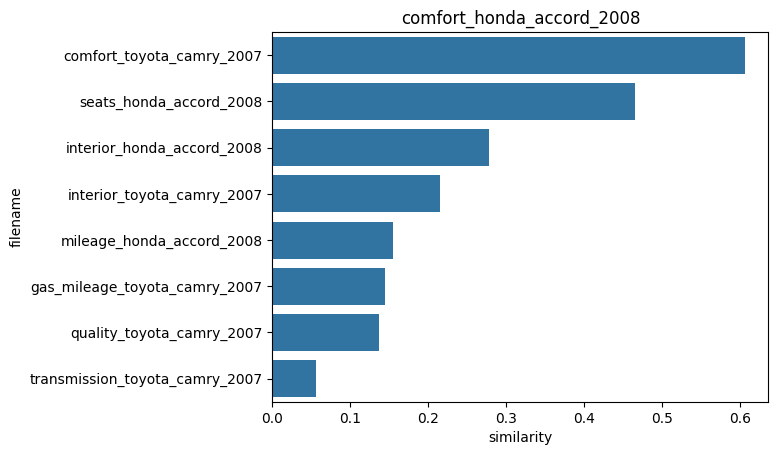

In [18]:
# cosine_similarity( )는 쌍 형태의 ndarray를 반환
# 이를 판다스 인덱스로 이용하기 위해 reshape(-1)로 차원을 변경

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 첫번째 문서와 타 문서간 유사도가 큰 순으로 정렬한 인덱스 추출하되 자기 자신은 제외
sorted_index = similarity_pair.argsort()[:,::-1]
sorted_index = sorted_index[:, 1:]

# 유사도가 큰 순으로 hotel_indexes를 추출하여 재정렬
hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]

# 유사도가 큰 순으로 유사도 값을 재정렬하되 자기 자신은 제외
hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value = hotel_1_sim_value[1:]

# 유사도가 큰 순으로 정렬된 인덱스와 유사도 값을 이용해 파일명과 유사도값을 막대 그래프로 시각화
hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename']
hotel_1_sim_df['similarity'] = hotel_1_sim_value
print('가장 유사도가 큰 파일명 및 유사도:\n', hotel_1_sim_df.iloc[0,:])

sns.barplot(x='similarity', y='filename', data=hotel_1_sim_df)
plt.title(comparison_docname)

- 첫 번째 문서인 comfort_honda_accord_2008 와 가장 비슷한 문서는 comfort_toyota_camry_2007.
- 약 0.606의 코사인 유사도 값을 나타냄.

# 09. 한글 텍스트 처리 - 네이버 영화 평점 감성 분석

- 한글 NLP 처리에서 주의할 점 & KoNLPy(파이썬 기반의 한글 형태소 패키지)
- 네이버 영화 평점 데이터 -> 감성 분석 적용

**한글 NLP 처리의 어려움**
- 한글 언어 처리가 어려운 이유
    - 띄어쓰기
    - 다양한 조사

**KoNLPy 소개**
- 파이썬의 대표적인 한글 형태소 패키지

In [19]:
pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 38.9 MB/s eta 0:00:00


In [20]:
# 데이터 로딩
# ratings_train.txt 파일을 DataFrame으로 로딩
# 한글로 된 문서 DataFrame으로 로딩 -> pd.read_csv()시 encoding을 cp949로 설정

import pandas as pd
train_df = pd.read_csv('/content/drive/MyDrive/ESAA/OB/data/ratings_train.txt', sep='\t', encoding='utf-8')
train_df.head(3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [21]:
# 학습 데이터 세트의 0과 1의 Label 값 비율 살펴보기
# 1이 긍정, 0이 부정 감성

train_df['label'].value_counts()

,count
label,
0,75173
1,74827


- 0과 1 비율이 균등하게 분포.

In [22]:
from tkinter.constants import X
import re

train_df = train_df.fillna(' ')

# 정규 표현식 re를 이용해 숫자를 공백으로 변경(정규 표현식으로 \d는 숫자를 의미함.)
train_df['document'] = train_df['document'].apply(lambda x: re.sub(r"\d+", " ", x))

# 테스트 데이터 세트를 로딩하고 동일하게 Null 및 숫자를 공백으로 변환
test_df = pd.read_csv('/content/drive/MyDrive/ESAA/OB/data/ratings_test.txt', sep='\t', encoding='utf-8')
test_df = test_df.fillna(' ')
test_df['document'] = test_df['document'].apply(lambda x: re.sub(r"\d+", " ", x))

In [23]:
# id칼럼 삭제
train_df.drop('id', axis=1, inplace=True)
test_df.drop('id', axis=1, inplace=True)

- TF-IDF 방식으로 단어 벡터화
- Twitter 객체의 morphs( ) 메서드 -> 입력 인자로 들어온 문장을 형태소 단어 형태로 토큰화해 list 객체로 반환함.

In [24]:
# tw_tokenizer( )함수 생성: 문장을 형태소 단어 형태로 반환

from konlpy.tag import Twitter

twitter = Twitter()
def tw_tokenizer(text):
    # 입력 인자로 들어온 텍스트를 형태소 단어로 토큰화해 리스트 형태로 반환
    tokens_ko = twitter.morphs(text)
    return tokens_ko

/usr/local/lib/python3.11/dist-packages/konlpy/tag/_okt.py:17: UserWarning: "Twitter" has changed to "Okt" since KoNLPy v0.4.5.
  warn('"Twitter" has changed to "Okt" since KoNLPy v0.4.5.')


In [25]:
# 사이킷런의 TfidfVectorizer를 이용해 TF-IDF 피처 모델 생성

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Twitter 객체의 morphs() 객체를 이용한 tokenizer 사용. ngram_range는 (1,2)
tfidf_vect = TfidfVectorizer(tokenizer=tw_tokenizer, ngram_range=(1,2), min_df=3, max_df=0.9)
tfidf_vect.fit(train_df['document'])
tfidf_matrix_train = tfidf_vect.transform(train_df['document'])

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [26]:
# 로지스틱 회귀를 이용해 감성 분석 분류 수행.
lg_clf = LogisticRegression(random_state=0, solver='liblinear')

# 파라미터 C 최적화를 위해 GridSearchCV를 이용
params = {'C': [1, 3.5, 4.5, 5.5, 10]}
grid_cv = GridSearchCV(lg_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv.fit(tfidf_matrix_train, train_df['label'])
print(grid_cv.best_params_, round(grid_cv.best_score_, 4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'C': 3.5} 0.8593


- C가 3.5일 때 최고 0.8593의 정확도를 보임.

- 테스트 세트를 이용해 최종 감성 분석 예측 수행
    - 테스트 세트를 이용해 예측할 때는 학습할 때 적용한 TfidfWctorizer를 그대로 사용해야 함.

In [27]:
# 학습 데이터에 사용된 TfidfVectorizer 객체 변수인 tfidf_vect를 이용
# transform()을 테스트 데이터의 document 칼럼에 수행

from sklearn.metrics import accuracy_score

# 학습 데이터를 적용한 TfidfVectorizer를 이용해 테스트 데이터를 TF-IDF 값으로 피처 변환
tfidf_matrix_test = tfidf_vect.transform(test_df['document'])

# classifier는 GridSearchCV에서 최적 파라미터로 학습된 classifier를 그대로 이용
best_estimator_ = grid_cv.best_estimator_
preds = best_estimator_.predict(tfidf_matrix_test)

print('Logistic Regression 정확도: ', accuracy_score(test_df['label'], preds))

Logistic Regression 정확도:  0.86172
